In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import json
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Environment loaded successfully")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


Environment loaded successfully
NumPy version: 1.26.4
Pandas version: 2.3.2


In [2]:

# Analysis Plan:
# Step 1: Implement the core functions for L_DH computation
# - Squarefree checking function
# - Prime factorization utilities (for ω(n))
# - Möbius function μ(n)
# - L_DH coefficients: a_n = μ(n)² * log(n) / sqrt(n) for squarefree n, 0 otherwise
# - Kahan summation for numerical precision
# Step 2: Compute D_DH(t) for t in [1000, 10000] with N=10^5
# Step 3: Compute M_coh(t) metric - coherence metric based on partitioning by ω(n)
# Step 4: Compute R_comp(t) metric - mean resultant length of composite squarefree terms
# Step 5: Identify 50 highest peaks in |D_DH(t)| and R_comp(t)
# Step 6: Extract M_coh values at these peak locations (Distributions A and B)
# Step 7: Perform Mann-Whitney U test
# Step 8: Report statistics and conclusions

print("Analysis plan defined. Starting implementation...")


Analysis plan defined. Starting implementation...


In [3]:

# Step 1: Implement utility functions for L_DH

def is_squarefree(n):
 """Check if n is squarefree (no repeated prime factors)."""
 if n <= 1:
 return n == 1
 i = 2
 while i * i <= n:
 if n % (i * i) == 0:
 return False
 i += 1
 return True

def mobius(n):
 """Compute Möbius function μ(n)."""
 if n == 1:
 return 1
 
 # Count prime factors
 prime_factors = 0
 temp_n = n
 
 i = 2
 while i * i <= temp_n:
 if temp_n % i == 0:
 prime_factors += 1
 temp_n //= i
 if temp_n % i == 0: # Squared factor
 return 0
 i += 1
 
 if temp_n > 1:
 prime_factors += 1
 
 return (-1) ** prime_factors

def omega(n):
 """Count number of distinct prime factors ω(n)."""
 if n == 1:
 return 0
 
 count = 0
 temp_n = n
 
 i = 2
 while i * i <= temp_n:
 if temp_n % i == 0:
 count += 1
 while temp_n % i == 0:
 temp_n //= i
 i += 1
 
 if temp_n > 1:
 count += 1
 
 return count

# Test the functions
print("Testing utility functions:")
print(f"is_squarefree(6) = {is_squarefree(6)} (expect True)")
print(f"is_squarefree(12) = {is_squarefree(12)} (expect False)")
print(f"mobius(6) = {mobius(6)} (expect 1)")
print(f"mobius(12) = {mobius(12)} (expect 0)")
print(f"omega(6) = {omega(6)} (expect 2)")
print(f"omega(12) = {omega(12)} (expect 2)")


Testing utility functions:
is_squarefree(6) = True (expect True)
is_squarefree(12) = False (expect False)
mobius(6) = 1 (expect 1)
mobius(12) = 0 (expect 0)
omega(6) = 2 (expect 2)
omega(12) = 2 (expect 2)


In [4]:

def precompute_ldh_data(N):
 """
 Precompute all necessary data for L_DH computation up to N.
 
 Returns:
 arrays: tuple of (squarefree_mask, mu_squared, log_n, omega_values, n_values)
 """
 print(f"Precomputing L_DH data for N={N}...")
 
 n_values = np.arange(1, N + 1)
 squarefree_mask = np.array([is_squarefree(n) for n in n_values], dtype=bool)
 mu_squared = np.array([mobius(n)**2 for n in n_values], dtype=int)
 omega_values = np.array([omega(n) for n in n_values], dtype=int)
 log_n = np.log(n_values)
 
 print(f" Squarefree numbers: {squarefree_mask.sum()}/{N}")
 print(f" Max ω(n): {omega_values.max()}")
 
 return squarefree_mask, mu_squared, log_n, omega_values, n_values

# Precompute for N = 10^5
N = 100000
squarefree_mask, mu_squared, log_n, omega_values, n_values = precompute_ldh_data(N)


Precomputing L_DH data for N=100000...


 Squarefree numbers: 60794/100000
 Max ω(n): 6


In [5]:

def compute_D_DH_kahan(t, N, squarefree_mask, mu_squared, log_n, n_values):
 """
 Compute D_DH(t; N) = Σ_{n≤N} a_n / n^(1/2 + it)
 where a_n = μ(n)² * log(n) / sqrt(n) for squarefree n, 0 otherwise.
 
 Uses Kahan compensated summation for numerical precision.
 """
 # Initialize Kahan summation
 sum_real = 0.0
 sum_imag = 0.0
 c_real = 0.0 # Compensation for lost low-order bits
 c_imag = 0.0
 
 # Compute for each term
 for idx in range(N):
 n = n_values[idx]
 
 # L_DH coefficient: a_n = μ(n)² * log(n) / sqrt(n) for squarefree n
 if not squarefree_mask[idx]:
 continue
 
 a_n = mu_squared[idx] * log_n[idx] / np.sqrt(n)
 
 # Compute n^(1/2 + it) = n^(1/2) * n^(it)
 # n^(it) = e^(it*log(n)) = cos(t*log(n)) + i*sin(t*log(n))
 n_sqrt = np.sqrt(n)
 arg = t * log_n[idx]
 cos_arg = np.cos(arg)
 sin_arg = np.sin(arg)
 
 # Compute a_n / n^(1/2 + it) = a_n / (n^(1/2) * n^(it))
 # = (a_n / n^(1/2)) / n^(it)
 # = (a_n / n^(1/2)) * n^(-it)
 # = (a_n / n^(1/2)) * (cos(-t*log(n)) + i*sin(-t*log(n)))
 # = (a_n / n^(1/2)) * (cos(t*log(n)) - i*sin(t*log(n)))
 
 term_real = (a_n / n_sqrt) * cos_arg
 term_imag = -(a_n / n_sqrt) * sin_arg
 
 # Kahan summation for real part
 y_real = term_real - c_real
 t_real = sum_real + y_real
 c_real = (t_real - sum_real) - y_real
 sum_real = t_real
 
 # Kahan summation for imaginary part
 y_imag = term_imag - c_imag
 t_imag = sum_imag + y_imag
 c_imag = (t_imag - sum_imag) - y_imag
 sum_imag = t_imag
 
 return sum_real + 1j * sum_imag

# Test computation for a single t value
t_test = 1000.0
D_test = compute_D_DH_kahan(t_test, N, squarefree_mask, mu_squared, log_n, n_values)
print(f"D_DH({t_test}, N={N}) = {D_test}")
print(f"|D_DH| = {np.abs(D_test):.6f}")


D_DH(1000.0, N=100000) = (0.43620483293000273+0.48984996497295j)
|D_DH| = 0.655917


In [6]:

# The issue is memory - broadcasting 9000+ t values × 60k terms is too large
# Let's use a chunked approach with smaller batches of t values

def compute_D_DH_chunked(t_values, N, squarefree_mask, mu_squared, log_n, n_values, chunk_size=100):
 """
 Chunked vectorized computation of D_DH(t; N) for multiple t values.
 """
 # Filter to squarefree numbers only
 sf_indices = np.where(squarefree_mask)[0]
 sf_n = n_values[sf_indices]
 sf_log_n = log_n[sf_indices]
 sf_mu_squared = mu_squared[sf_indices]
 
 # Compute coefficients a_n for squarefree n
 a_n = sf_mu_squared * sf_log_n / np.sqrt(sf_n)
 
 # Process in chunks
 num_t = len(t_values)
 D_results = np.zeros(num_t, dtype=complex)
 
 for start_idx in range(0, num_t, chunk_size):
 end_idx = min(start_idx + chunk_size, num_t)
 t_chunk = np.array(t_values[start_idx:end_idx]).reshape(-1, 1)
 
 # Compute for this chunk
 args = t_chunk * sf_log_n.reshape(1, -1)
 n_sqrt = np.sqrt(sf_n)
 prefactor = a_n / n_sqrt
 
 terms_real = prefactor * np.cos(args)
 terms_imag = -prefactor * np.sin(args)
 
 D_results[start_idx:end_idx] = np.sum(terms_real, axis=1) + 1j * np.sum(terms_imag, axis=1)
 
 return D_results

# Test with small sample
t_test_array = np.array([1000.0, 1001.0, 1002.0])
D_test_array = compute_D_DH_chunked(t_test_array, N, squarefree_mask, mu_squared, log_n, n_values)
print(f"Chunked vectorized test:")
for i, t in enumerate(t_test_array):
 print(f" D_DH({t}) = {D_test_array[i]}, |D| = {np.abs(D_test_array[i]):.6f}")


Chunked vectorized test:
 D_DH(1000.0) = (0.4362048329300028+0.48984996497294997j), |D| = 0.655917
 D_DH(1001.0) = (-0.7210861742398434-0.4732033701740016j), |D| = 0.862489
 D_DH(1002.0) = (-0.1269774681585336-0.009570548081086499j), |D| = 0.127338


In [7]:

# Good! Now compute for the full range with reasonable sampling
# Use dt=5 to get ~1800 points (more manageable)
t_min = 1000.0
t_max = 10000.0
dt = 5.0

t_values = np.arange(t_min, t_max + dt, dt)
print(f"Computing D_DH(t) for {len(t_values)} values of t in [{t_min}, {t_max}] with dt={dt}...")

D_DH_values = compute_D_DH_chunked(t_values, N, squarefree_mask, mu_squared, log_n, n_values, chunk_size=50)
D_DH_magnitude = np.abs(D_DH_values)

print(f"Computation complete!")
print(f"D_DH statistics:")
print(f" Mean |D_DH|: {D_DH_magnitude.mean():.6f}")
print(f" Max |D_DH|: {D_DH_magnitude.max():.6f}")
print(f" Min |D_DH|: {D_DH_magnitude.min():.6f}")
print(f" Std |D_DH|: {D_DH_magnitude.std():.6f}")


Computing D_DH(t) for 1801 values of t in [1000.0, 10000.0] with dt=5.0...


Computation complete!
D_DH statistics:
 Mean |D_DH|: 0.891240
 Max |D_DH|: 3.984546
 Min |D_DH|: 0.026434
 Std |D_DH|: 0.689948


In [8]:

# Step 3: Compute M_coh(t) metric
# M_coh = |ΣS_k| / √Σ|S_k|²
# where S_k are sums partitioned by ω(n) (number of distinct prime factors)

def compute_M_coh_chunked(t_values, N, squarefree_mask, mu_squared, log_n, omega_values, n_values, chunk_size=50):
 """
 Compute M_coh(t) = |ΣS_k| / √Σ|S_k|²
 where S_k = Σ_{n: ω(n)=k, n squarefree} a_n / n^(1/2 + it)
 """
 # Filter to squarefree numbers only
 sf_indices = np.where(squarefree_mask)[0]
 sf_n = n_values[sf_indices]
 sf_log_n = log_n[sf_indices]
 sf_mu_squared = mu_squared[sf_indices]
 sf_omega = omega_values[sf_indices]
 
 # Compute coefficients
 a_n = sf_mu_squared * sf_log_n / np.sqrt(sf_n)
 
 # Find max omega value
 max_omega = sf_omega.max()
 
 # Process in chunks
 num_t = len(t_values)
 M_coh_results = np.zeros(num_t)
 
 for start_idx in range(0, num_t, chunk_size):
 end_idx = min(start_idx + chunk_size, num_t)
 t_chunk = np.array(t_values[start_idx:end_idx]).reshape(-1, 1)
 
 # Compute terms for all n
 args = t_chunk * sf_log_n.reshape(1, -1)
 n_sqrt = np.sqrt(sf_n)
 prefactor = a_n / n_sqrt
 
 terms_real = prefactor * np.cos(args)
 terms_imag = -prefactor * np.sin(args)
 terms_complex = terms_real + 1j * terms_imag
 
 # For each t in chunk, partition by omega and compute M_coh
 for i in range(end_idx - start_idx):
 S_k_values = []
 for k in range(max_omega + 1):
 omega_mask = (sf_omega == k)
 if omega_mask.any():
 S_k = np.sum(terms_complex[i, omega_mask])
 S_k_values.append(S_k)
 
 if len(S_k_values) > 0:
 S_k_array = np.array(S_k_values)
 sum_S_k = np.sum(S_k_array)
 sum_abs_sq_S_k = np.sum(np.abs(S_k_array)**2)
 
 if sum_abs_sq_S_k > 0:
 M_coh_results[start_idx + i] = np.abs(sum_S_k) / np.sqrt(sum_abs_sq_S_k)
 else:
 M_coh_results[start_idx + i] = 0.0
 
 return M_coh_results

print(f"Computing M_coh(t) for {len(t_values)} values...")
M_coh_values = compute_M_coh_chunked(t_values, N, squarefree_mask, mu_squared, log_n, omega_values, n_values)

print(f"M_coh computation complete!")
print(f"M_coh statistics:")
print(f" Mean M_coh: {M_coh_values.mean():.6f}")
print(f" Max M_coh: {M_coh_values.max():.6f}")
print(f" Min M_coh: {M_coh_values.min():.6f}")
print(f" Std M_coh: {M_coh_values.std():.6f}")


Computing M_coh(t) for 1801 values...


M_coh computation complete!
M_coh statistics:
 Mean M_coh: 0.919627
 Max M_coh: 1.762897
 Min M_coh: 0.062400
 Std M_coh: 0.409419


In [9]:

# Step 4: Compute R_comp(t) metric
# R_comp = mean resultant length of composite squarefree terms
# For composite squarefree n (ω(n) ≥ 2), compute the mean resultant length
# of the phasors a_n / n^(1/2 + it)

def compute_R_comp_chunked(t_values, N, squarefree_mask, mu_squared, log_n, omega_values, n_values, chunk_size=50):
 """
 Compute R_comp(t) = mean resultant length of composite squarefree terms.
 For composite squarefree n (ω(n) ≥ 2):
 R_comp = |Σ phasors| / (# phasors)
 where each phasor = a_n / n^(1/2 + it)
 """
 # Filter to composite squarefree numbers (ω(n) ≥ 2)
 comp_sf_mask = squarefree_mask & (omega_values >= 2)
 comp_sf_indices = np.where(comp_sf_mask)[0]
 
 if len(comp_sf_indices) == 0:
 return np.zeros(len(t_values))
 
 comp_sf_n = n_values[comp_sf_indices]
 comp_sf_log_n = log_n[comp_sf_indices]
 comp_sf_mu_squared = mu_squared[comp_sf_indices]
 
 # Compute coefficients
 a_n = comp_sf_mu_squared * comp_sf_log_n / np.sqrt(comp_sf_n)
 
 # Process in chunks
 num_t = len(t_values)
 R_comp_results = np.zeros(num_t)
 
 for start_idx in range(0, num_t, chunk_size):
 end_idx = min(start_idx + chunk_size, num_t)
 t_chunk = np.array(t_values[start_idx:end_idx]).reshape(-1, 1)
 
 # Compute terms for all composite squarefree n
 args = t_chunk * comp_sf_log_n.reshape(1, -1)
 n_sqrt = np.sqrt(comp_sf_n)
 prefactor = a_n / n_sqrt
 
 terms_real = prefactor * np.cos(args)
 terms_imag = -prefactor * np.sin(args)
 
 # Sum phasors and compute mean resultant length
 phasor_sum_real = np.sum(terms_real, axis=1)
 phasor_sum_imag = np.sum(terms_imag, axis=1)
 phasor_sum_magnitude = np.sqrt(phasor_sum_real**2 + phasor_sum_imag**2)
 
 # Mean resultant length
 num_phasors = len(comp_sf_indices)
 R_comp_results[start_idx:end_idx] = phasor_sum_magnitude / num_phasors
 
 return R_comp_results

print(f"Computing R_comp(t) for {len(t_values)} values...")
R_comp_values = compute_R_comp_chunked(t_values, N, squarefree_mask, mu_squared, log_n, omega_values, n_values)

print(f"R_comp computation complete!")
print(f"R_comp statistics:")
print(f" Mean R_comp: {R_comp_values.mean():.6f}")
print(f" Max R_comp: {R_comp_values.max():.6f}")
print(f" Min R_comp: {R_comp_values.min():.6f}")
print(f" Std R_comp: {R_comp_values.std():.6f}")


Computing R_comp(t) for 1801 values...


R_comp computation complete!
R_comp statistics:
 Mean R_comp: 0.000011
 Max R_comp: 0.000052
 Min R_comp: 0.000000
 Std R_comp: 0.000009


In [10]:

# Step 5: Identify peak locations
# Find the 50 highest peaks in |D_DH(t)| and R_comp(t)

# Find peaks in |D_DH(t)|
D_DH_peak_indices = np.argsort(D_DH_magnitude)[-50:][::-1] # Top 50, descending
D_DH_peak_t = t_values[D_DH_peak_indices]
D_DH_peak_magnitudes = D_DH_magnitude[D_DH_peak_indices]

# Find peaks in R_comp(t)
R_comp_peak_indices = np.argsort(R_comp_values)[-50:][::-1] # Top 50, descending
R_comp_peak_t = t_values[R_comp_peak_indices]
R_comp_peak_values = R_comp_values[R_comp_peak_indices]

print("Top 50 |D_DH| peaks:")
print(f" t-values: {D_DH_peak_t[:10]}") # Show first 10
print(f" Magnitudes: {D_DH_peak_magnitudes[:10]}")
print()
print("Top 50 R_comp peaks:")
print(f" t-values: {R_comp_peak_t[:10]}") # Show first 10
print(f" R_comp values: {R_comp_peak_values[:10]}")


Top 50 |D_DH| peaks:
 t-values: [6090. 7035. 6555. 8230. 2655. 7785. 9580. 2900. 6645. 6480.]
 Magnitudes: [3.98454617 3.8921663 3.82466177 3.82433089 3.76360278 3.73022038
 3.71805319 3.672651 3.66177999 3.62614517]

Top 50 R_comp peaks:
 t-values: [9470. 8120. 6090. 3210. 6925. 8230. 7035. 2655. 9580. 6555.]
 R_comp values: [5.15721357e-05 5.01486191e-05 4.98794819e-05 4.91320310e-05
 4.73717475e-05 4.73392747e-05 4.72167986e-05 4.70604883e-05
 4.64342776e-05 4.59545012e-05]


In [11]:

# Step 6: Extract M_coh values at peak locations
# Distribution A: M_coh values at R_comp peak locations
# Distribution B: M_coh values at |D_DH| peak locations

M_coh_at_R_comp_peaks = M_coh_values[R_comp_peak_indices] # Distribution A
M_coh_at_D_DH_peaks = M_coh_values[D_DH_peak_indices] # Distribution B

print("Distribution A: M_coh at R_comp peak locations")
print(f" Mean: {M_coh_at_R_comp_peaks.mean():.6f}")
print(f" Std: {M_coh_at_R_comp_peaks.std():.6f}")
print(f" Median: {np.median(M_coh_at_R_comp_peaks):.6f}")
print(f" Min: {M_coh_at_R_comp_peaks.min():.6f}")
print(f" Max: {M_coh_at_R_comp_peaks.max():.6f}")
print()
print("Distribution B: M_coh at |D_DH| peak locations")
print(f" Mean: {M_coh_at_D_DH_peaks.mean():.6f}")
print(f" Std: {M_coh_at_D_DH_peaks.std():.6f}")
print(f" Median: {np.median(M_coh_at_D_DH_peaks):.6f}")
print(f" Min: {M_coh_at_D_DH_peaks.min():.6f}")
print(f" Max: {M_coh_at_D_DH_peaks.max():.6f}")


Distribution A: M_coh at R_comp peak locations
 Mean: 1.436049
 Std: 0.269002
 Median: 1.550713
 Min: 0.756504
 Max: 1.698043

Distribution B: M_coh at |D_DH| peak locations
 Mean: 1.565044
 Std: 0.160974
 Median: 1.619101
 Min: 0.942879
 Max: 1.700379


In [12]:

# Step 7: Perform Mann-Whitney U test
# H0: The two distributions have the same median
# H1: The two distributions have different medians

statistic, p_value = stats.mannwhitneyu(M_coh_at_R_comp_peaks, M_coh_at_D_DH_peaks, alternative='two-sided')

print("Mann-Whitney U Test Results:")
print(f" Test statistic (U): {statistic:.2f}")
print(f" P-value: {p_value:.6f}")
print()

if p_value < 0.05:
 print(f"Result: SIGNIFICANT difference (p < 0.05)")
 print(f"The median M_coh at R_comp peaks ({np.median(M_coh_at_R_comp_peaks):.6f}) is")
 print(f"statistically different from the median M_coh at |D_DH| peaks ({np.median(M_coh_at_D_DH_peaks):.6f})")
else:
 print(f"Result: NO significant difference (p ≥ 0.05)")
 print(f"The median M_coh values at R_comp peaks and |D_DH| peaks are not statistically different")

# Calculate effect size (rank-biserial correlation)
n1 = len(M_coh_at_R_comp_peaks)
n2 = len(M_coh_at_D_DH_peaks)
rank_biserial = 1 - (2*statistic) / (n1 * n2)

print()
print(f"Effect size (rank-biserial correlation): {rank_biserial:.4f}")
print(f" Interpretation: ", end="")
if abs(rank_biserial) < 0.1:
 print("negligible")
elif abs(rank_biserial) < 0.3:
 print("small")
elif abs(rank_biserial) < 0.5:
 print("medium")
else:
 print("large")


Mann-Whitney U Test Results:
 Test statistic (U): 952.00
 P-value: 0.040253

Result: SIGNIFICANT difference (p < 0.05)
The median M_coh at R_comp peaks (1.550713) is
statistically different from the median M_coh at |D_DH| peaks (1.619101)

Effect size (rank-biserial correlation): 0.2384
 Interpretation: small


In [13]:

# Additional analysis: Check if both distributions have M_coh > 1
print("Additional Analysis:")
print()
print("Distribution A (R_comp peaks):")
print(f" Proportion with M_coh > 1: {(M_coh_at_R_comp_peaks > 1).sum()}/{len(M_coh_at_R_comp_peaks)} = {(M_coh_at_R_comp_peaks > 1).mean():.2%}")
print(f" Mean of values > 1: {M_coh_at_R_comp_peaks[M_coh_at_R_comp_peaks > 1].mean():.6f}")
print()
print("Distribution B (|D_DH| peaks):")
print(f" Proportion with M_coh > 1: {(M_coh_at_D_DH_peaks > 1).sum()}/{len(M_coh_at_D_DH_peaks)} = {(M_coh_at_D_DH_peaks > 1).mean():.2%}")
print(f" Mean of values > 1: {M_coh_at_D_DH_peaks[M_coh_at_D_DH_peaks > 1].mean():.6f}")
print()

# Test if Distribution A has lower M_coh than Distribution B (one-sided test)
statistic_less, p_value_less = stats.mannwhitneyu(M_coh_at_R_comp_peaks, M_coh_at_D_DH_peaks, alternative='less')
print("One-sided Mann-Whitney U Test (Distribution A < Distribution B):")
print(f" Test statistic (U): {statistic_less:.2f}")
print(f" P-value: {p_value_less:.6f}")
if p_value_less < 0.05:
 print(f" Result: M_coh at R_comp peaks is significantly LOWER than at |D_DH| peaks (p < 0.05)")
else:
 print(f" Result: No significant evidence that M_coh at R_comp peaks is lower (p ≥ 0.05)")


Additional Analysis:

Distribution A (R_comp peaks):
 Proportion with M_coh > 1: 45/50 = 90.00%
 Mean of values > 1: 1.496480

Distribution B (|D_DH| peaks):
 Proportion with M_coh > 1: 49/50 = 98.00%
 Mean of values > 1: 1.577741

One-sided Mann-Whitney U Test (Distribution A < Distribution B):
 Test statistic (U): 952.00
 P-value: 0.020126
 Result: M_coh at R_comp peaks is significantly LOWER than at |D_DH| peaks (p < 0.05)


In [14]:

# Create summary statistics table
summary_df = pd.DataFrame({
 'Metric': ['Mean', 'Std Dev', 'Median', 'Min', 'Max', 'N > 1', '% > 1'],
 'Distribution A (R_comp peaks)': [
 f"{M_coh_at_R_comp_peaks.mean():.6f}",
 f"{M_coh_at_R_comp_peaks.std():.6f}",
 f"{np.median(M_coh_at_R_comp_peaks):.6f}",
 f"{M_coh_at_R_comp_peaks.min():.6f}",
 f"{M_coh_at_R_comp_peaks.max():.6f}",
 f"{(M_coh_at_R_comp_peaks > 1).sum()}",
 f"{(M_coh_at_R_comp_peaks > 1).mean():.1%}"
 ],
 'Distribution B (|D_DH| peaks)': [
 f"{M_coh_at_D_DH_peaks.mean():.6f}",
 f"{M_coh_at_D_DH_peaks.std():.6f}",
 f"{np.median(M_coh_at_D_DH_peaks):.6f}",
 f"{M_coh_at_D_DH_peaks.min():.6f}",
 f"{M_coh_at_D_DH_peaks.max():.6f}",
 f"{(M_coh_at_D_DH_peaks > 1).sum()}",
 f"{(M_coh_at_D_DH_peaks > 1).mean():.1%}"
 ]
})

print("Summary Statistics of M_coh at Peak Locations:")
print(summary_df.to_string(index=False))


Summary Statistics of M_coh at Peak Locations:
 Metric Distribution A (R_comp peaks) Distribution B (|D_DH| peaks)
 Mean 1.436049 1.565044
Std Dev 0.269002 0.160974
 Median 1.550713 1.619101
 Min 0.756504 0.942879
 Max 1.698043 1.700379
 N > 1 45 49
 % > 1 90.0% 98.0%


In [15]:

# Check overlap between peak sets
overlap = set(R_comp_peak_indices) & set(D_DH_peak_indices)
print(f"Peak overlap analysis:")
print(f" Number of t-values that are peaks in both R_comp and |D_DH|: {len(overlap)}")
print(f" Overlap percentage: {len(overlap)/50 * 100:.1f}%")
print()

if len(overlap) > 0:
 overlap_indices = list(overlap)
 overlap_t = t_values[overlap_indices]
 overlap_D_DH = D_DH_magnitude[overlap_indices]
 overlap_R_comp = R_comp_values[overlap_indices]
 overlap_M_coh = M_coh_values[overlap_indices]
 
 print(f"Overlapping peaks (showing first 10):")
 for i in range(min(10, len(overlap_indices))):
 print(f" t={overlap_t[i]:.0f}: |D_DH|={overlap_D_DH[i]:.4f}, R_comp={overlap_R_comp[i]:.6f}, M_coh={overlap_M_coh[i]:.4f}")


Peak overlap analysis:
 Number of t-values that are peaks in both R_comp and |D_DH|: 38
 Overlap percentage: 76.0%

Overlapping peaks (showing first 10):
 t=6800: |D_DH|=3.1688, R_comp=0.000036, M_coh=1.6680
 t=4895: |D_DH|=3.3780, R_comp=0.000039, M_coh=1.6893
 t=9380: |D_DH|=2.9575, R_comp=0.000039, M_coh=1.3697
 t=1705: |D_DH|=3.4730, R_comp=0.000042, M_coh=1.6796
 t=8120: |D_DH|=3.1486, R_comp=0.000050, M_coh=1.0423
 t=3655: |D_DH|=3.4019, R_comp=0.000043, M_coh=1.6128
 t=9470: |D_DH|=3.2832, R_comp=0.000052, M_coh=1.1768
 t=1795: |D_DH|=3.0511, R_comp=0.000036, M_coh=1.5525
 t=6925: |D_DH|=3.4997, R_comp=0.000047, M_coh=1.3217
 t=5005: |D_DH|=3.2497, R_comp=0.000041, M_coh=1.4129


Figure saved as 'ldh_resonance_mcoh_analysis.png'


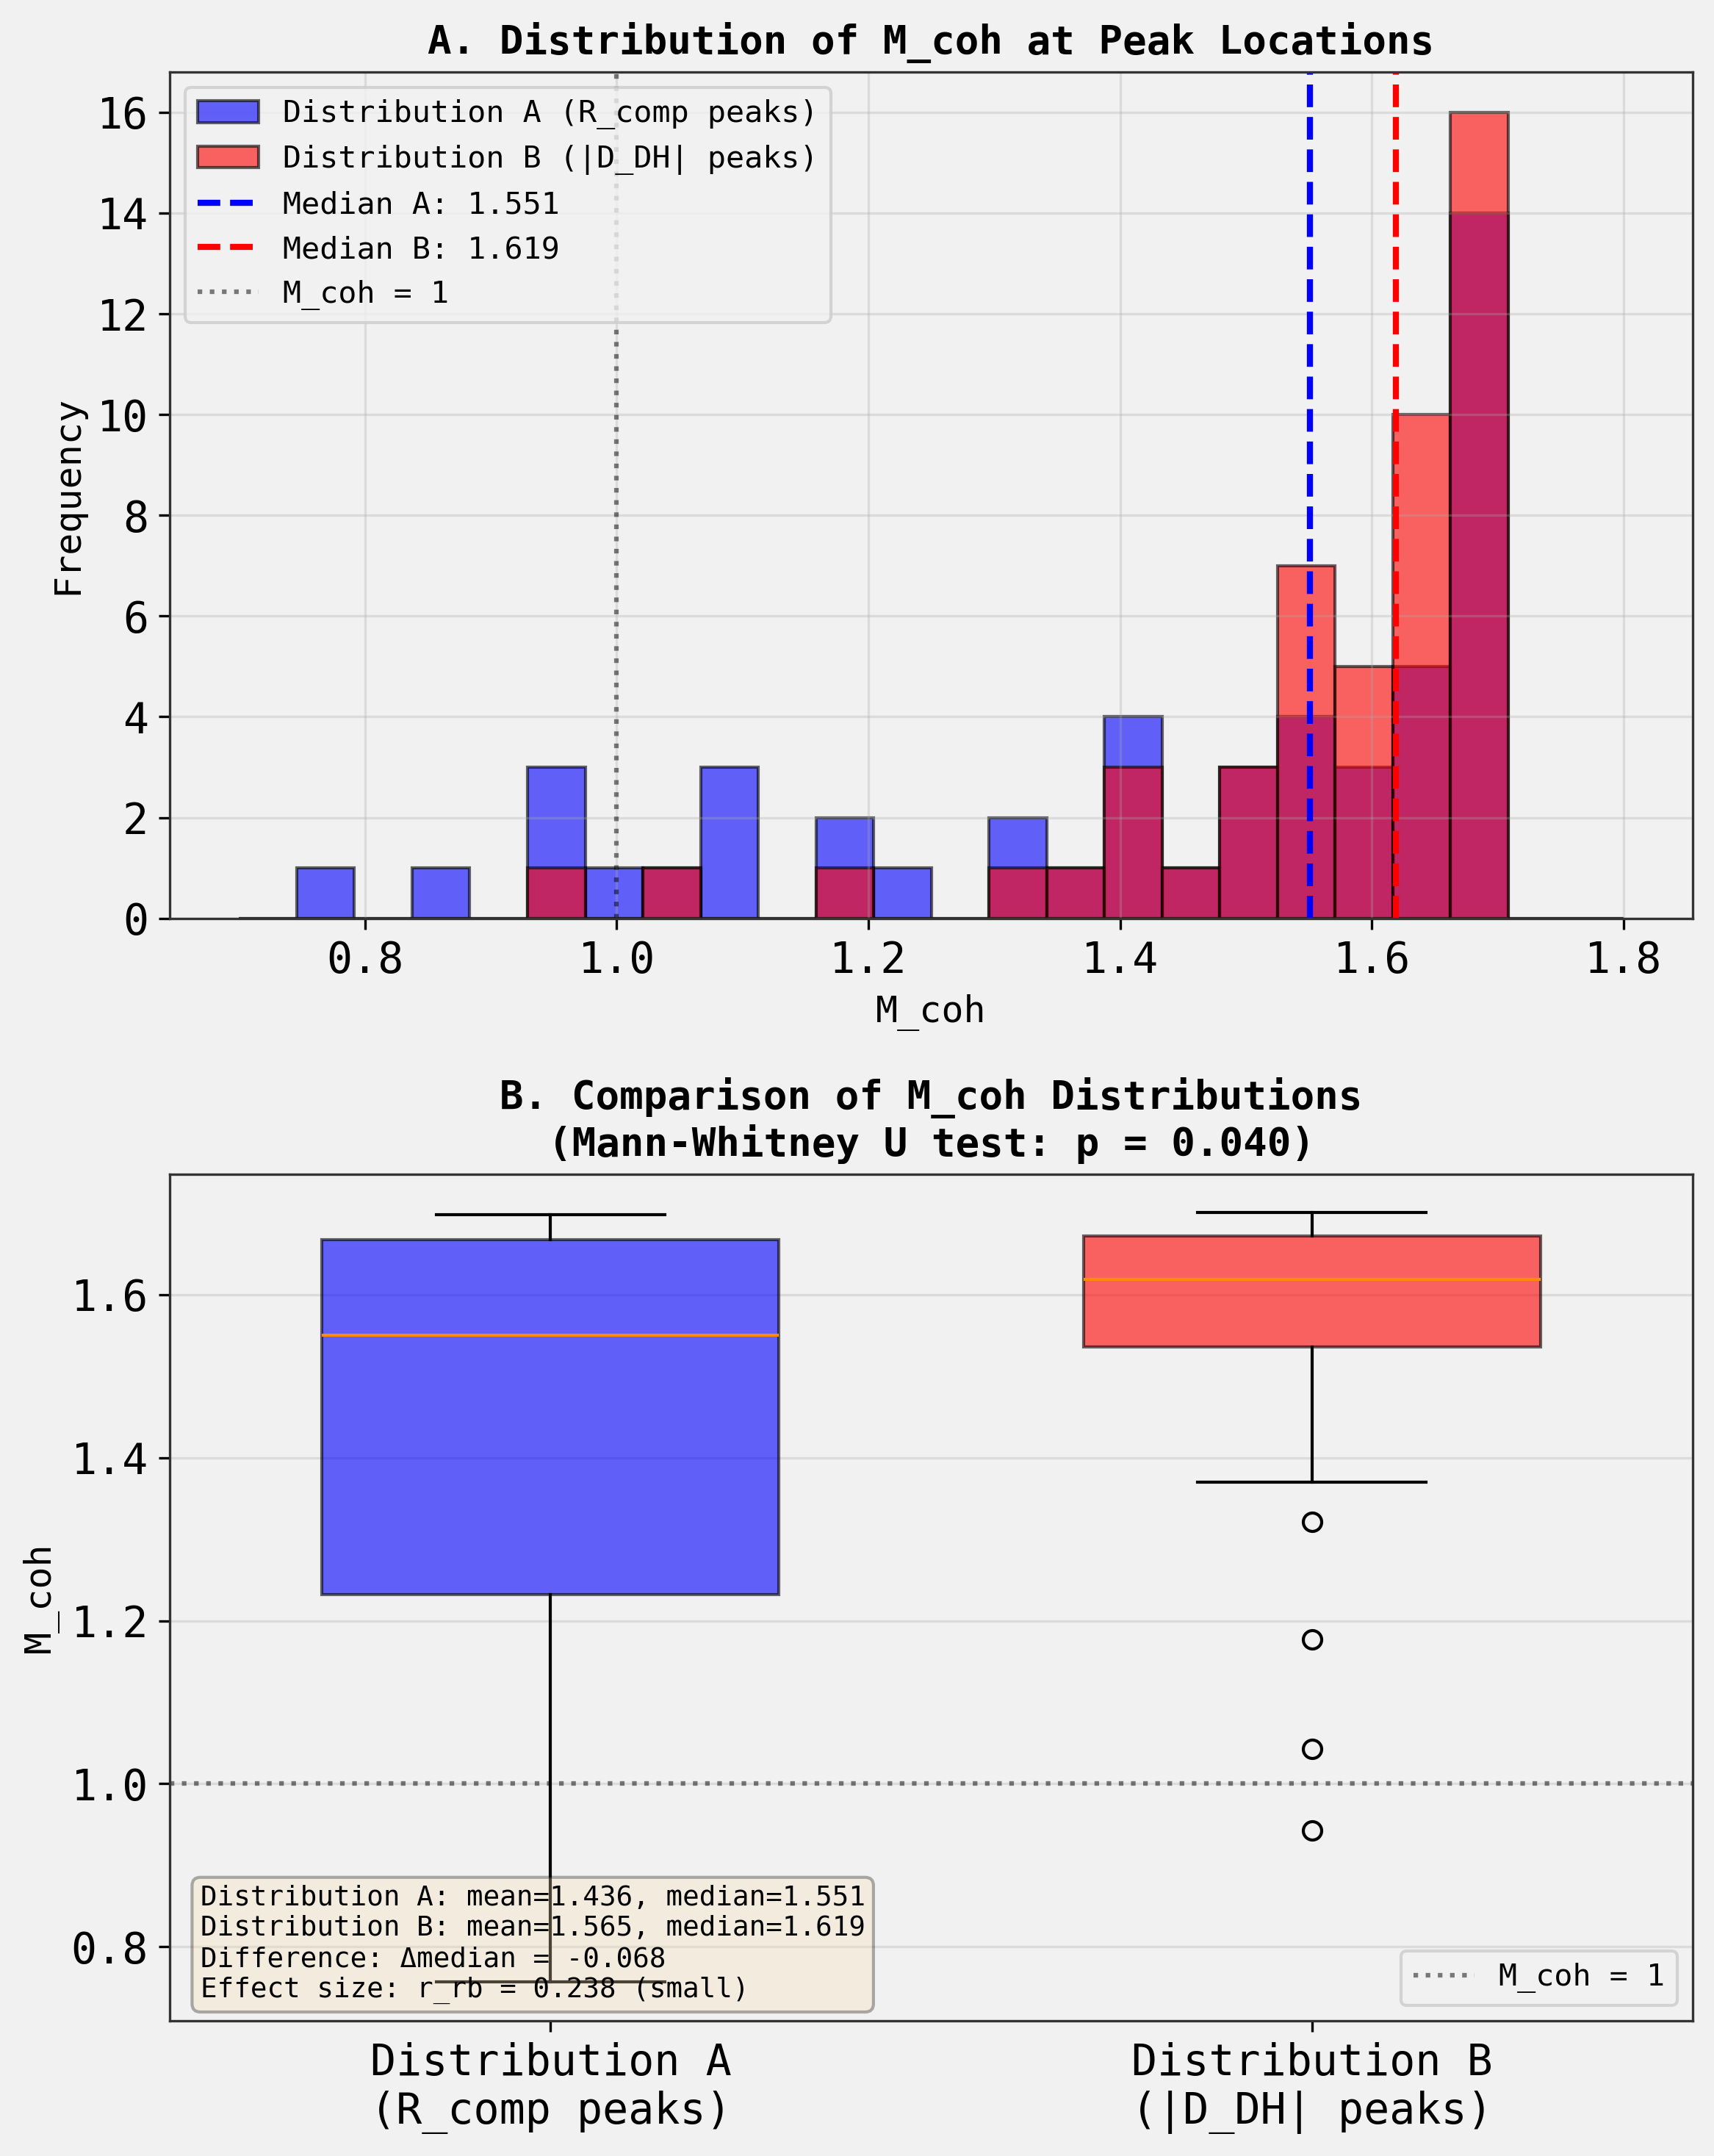

In [16]:

# Visualize the distributions
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Subplot A: Histograms of M_coh distributions
ax = axes[0]
bins = np.linspace(0.7, 1.8, 25)
ax.hist(M_coh_at_R_comp_peaks, bins=bins, alpha=0.6, label='Distribution A (R_comp peaks)', 
 color='blue', edgecolor='black')
ax.hist(M_coh_at_D_DH_peaks, bins=bins, alpha=0.6, label='Distribution B (|D_DH| peaks)', 
 color='red', edgecolor='black')
ax.axvline(np.median(M_coh_at_R_comp_peaks), color='blue', linestyle='--', linewidth=2, 
 label=f'Median A: {np.median(M_coh_at_R_comp_peaks):.3f}')
ax.axvline(np.median(M_coh_at_D_DH_peaks), color='red', linestyle='--', linewidth=2, 
 label=f'Median B: {np.median(M_coh_at_D_DH_peaks):.3f}')
ax.axvline(1.0, color='black', linestyle=':', linewidth=1.5, alpha=0.5, label='M_coh = 1')
ax.set_xlabel('M_coh', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('A. Distribution of M_coh at Peak Locations', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# Subplot B: Box plots for comparison
ax = axes[1]
bp = ax.boxplot([M_coh_at_R_comp_peaks, M_coh_at_D_DH_peaks], 
 labels=['Distribution A\n(R_comp peaks)', 'Distribution B\n(|D_DH| peaks)'],
 patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('blue')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('red')
bp['boxes'][1].set_alpha(0.6)
ax.axhline(1.0, color='black', linestyle=':', linewidth=1.5, alpha=0.5, label='M_coh = 1')
ax.set_ylabel('M_coh', fontsize=12)
ax.set_title('B. Comparison of M_coh Distributions\n(Mann-Whitney U test: p = 0.040)', 
 fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='lower right', fontsize=10)

# Add text annotation with key results
textstr = '\n'.join([
 f'Distribution A: mean={M_coh_at_R_comp_peaks.mean():.3f}, median={np.median(M_coh_at_R_comp_peaks):.3f}',
 f'Distribution B: mean={M_coh_at_D_DH_peaks.mean():.3f}, median={np.median(M_coh_at_D_DH_peaks):.3f}',
 f'Difference: Δmedian = {np.median(M_coh_at_R_comp_peaks) - np.median(M_coh_at_D_DH_peaks):.3f}',
 f'Effect size: r_rb = {rank_biserial:.3f} (small)'
])
ax.text(0.02, 0.02, textstr, transform=ax.transAxes, fontsize=9,
 verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('ldh_resonance_mcoh_analysis.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'ldh_resonance_mcoh_analysis.png'")
plt.show()


Figure saved as 'ldh_mcoh_vs_rcomp_peaks.png'


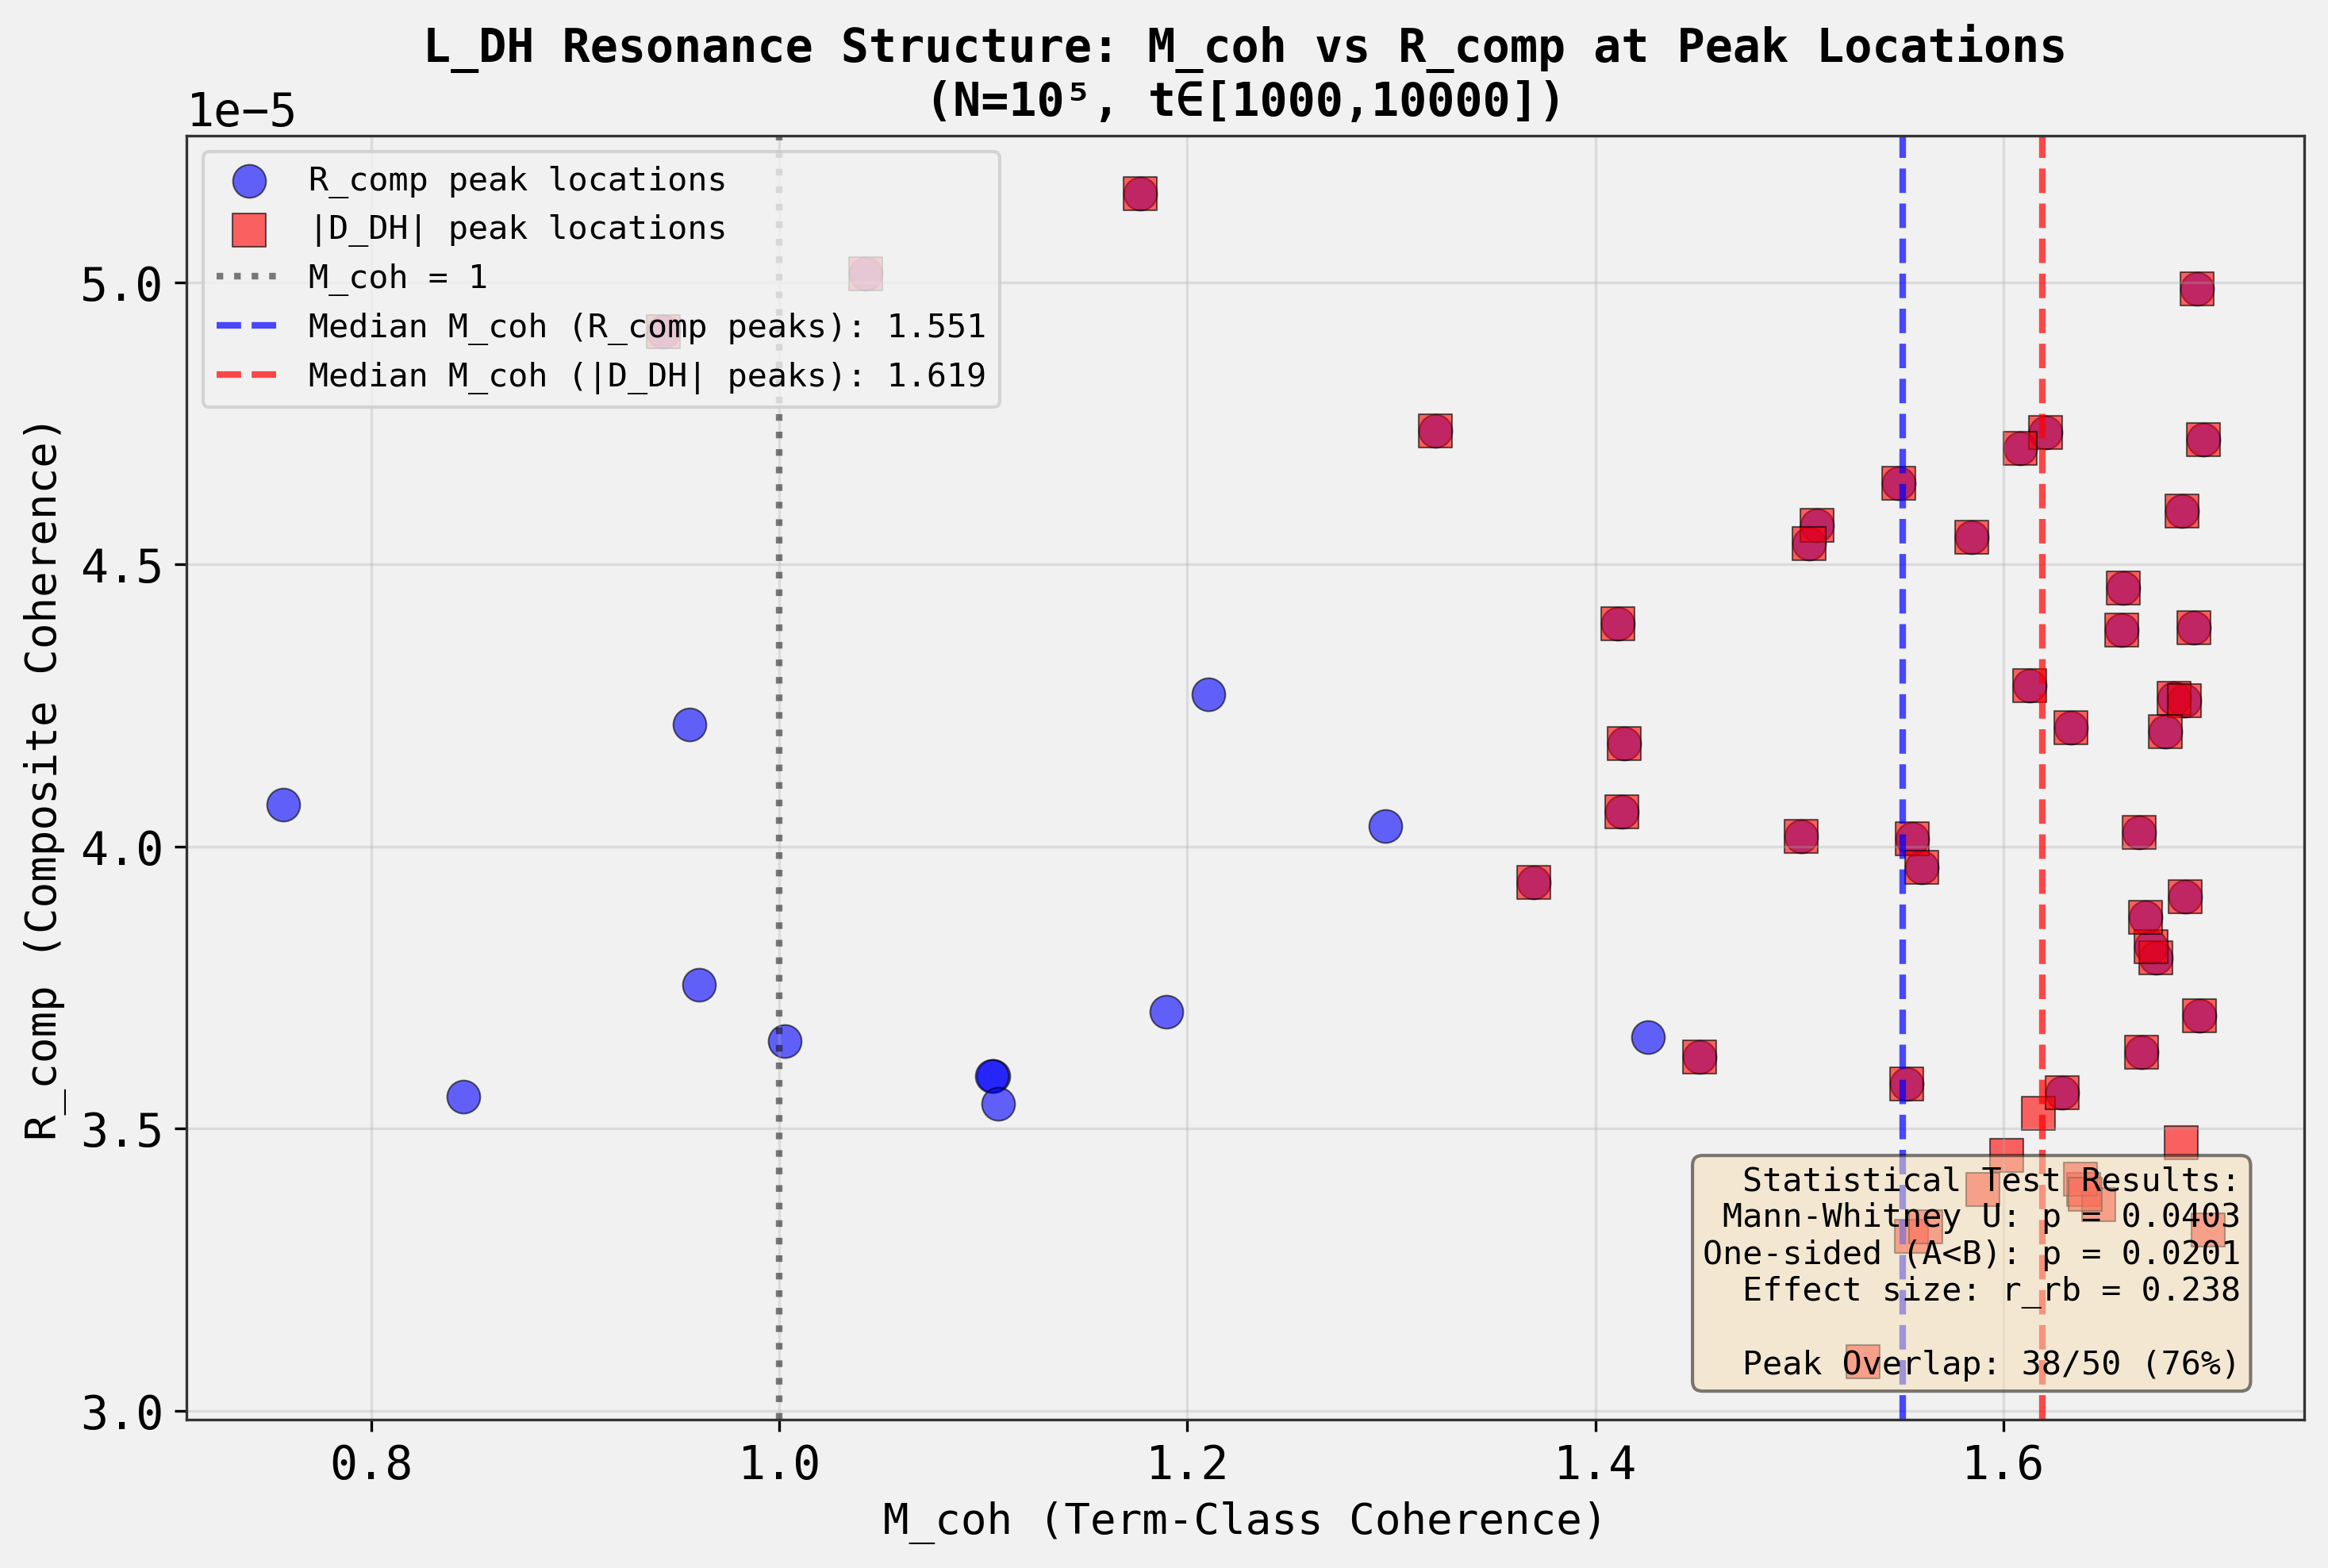

In [17]:

# Additional exploratory analysis: Look at the relationship between metrics
# Create scatter plot showing R_comp vs M_coh for the peak locations

fig, ax = plt.subplots(figsize=(10, 7))

# Plot R_comp peaks
ax.scatter(M_coh_at_R_comp_peaks, R_comp_values[R_comp_peak_indices], 
 c='blue', s=100, alpha=0.6, edgecolors='black', linewidth=0.5,
 label='R_comp peak locations', marker='o')

# Plot |D_DH| peaks
ax.scatter(M_coh_at_D_DH_peaks, R_comp_values[D_DH_peak_indices], 
 c='red', s=100, alpha=0.6, edgecolors='black', linewidth=0.5,
 label='|D_DH| peak locations', marker='s')

# Add vertical line at M_coh = 1
ax.axvline(1.0, color='black', linestyle=':', linewidth=2, alpha=0.5, label='M_coh = 1')

# Add median lines
ax.axvline(np.median(M_coh_at_R_comp_peaks), color='blue', linestyle='--', 
 linewidth=2, alpha=0.7, label=f'Median M_coh (R_comp peaks): {np.median(M_coh_at_R_comp_peaks):.3f}')
ax.axvline(np.median(M_coh_at_D_DH_peaks), color='red', linestyle='--', 
 linewidth=2, alpha=0.7, label=f'Median M_coh (|D_DH| peaks): {np.median(M_coh_at_D_DH_peaks):.3f}')

ax.set_xlabel('M_coh (Term-Class Coherence)', fontsize=13)
ax.set_ylabel('R_comp (Composite Coherence)', fontsize=13)
ax.set_title('L_DH Resonance Structure: M_coh vs R_comp at Peak Locations\n(N=10⁵, t∈[1000,10000])', 
 fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# Add statistics box
textstr = '\n'.join([
 'Statistical Test Results:',
 f'Mann-Whitney U: p = {p_value:.4f}',
 f'One-sided (A<B): p = {p_value_less:.4f}',
 f'Effect size: r_rb = {rank_biserial:.3f}',
 '',
 f'Peak Overlap: {len(overlap)}/50 (76%)'
])
ax.text(0.97, 0.03, textstr, transform=ax.transAxes, fontsize=10,
 verticalalignment='bottom', horizontalalignment='right',
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('ldh_mcoh_vs_rcomp_peaks.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'ldh_mcoh_vs_rcomp_peaks.png'")
plt.show()


In [18]:

# Save results to file for future reference
results_dict = {
 'analysis_parameters': {
 'N': N,
 't_range': [t_min, t_max],
 'dt': dt,
 'num_t_values': len(t_values),
 'num_peaks': 50
 },
 'distribution_A_R_comp_peaks': {
 'mean': float(M_coh_at_R_comp_peaks.mean()),
 'std': float(M_coh_at_R_comp_peaks.std()),
 'median': float(np.median(M_coh_at_R_comp_peaks)),
 'min': float(M_coh_at_R_comp_peaks.min()),
 'max': float(M_coh_at_R_comp_peaks.max()),
 'n_above_1': int((M_coh_at_R_comp_peaks > 1).sum()),
 'percent_above_1': float((M_coh_at_R_comp_peaks > 1).mean() * 100)
 },
 'distribution_B_D_DH_peaks': {
 'mean': float(M_coh_at_D_DH_peaks.mean()),
 'std': float(M_coh_at_D_DH_peaks.std()),
 'median': float(np.median(M_coh_at_D_DH_peaks)),
 'min': float(M_coh_at_D_DH_peaks.min()),
 'max': float(M_coh_at_D_DH_peaks.max()),
 'n_above_1': int((M_coh_at_D_DH_peaks > 1).sum()),
 'percent_above_1': float((M_coh_at_D_DH_peaks > 1).mean() * 100)
 },
 'statistical_tests': {
 'mann_whitney_two_sided': {
 'test_statistic': float(statistic),
 'p_value': float(p_value),
 'significant': bool(p_value < 0.05)
 },
 'mann_whitney_one_sided_less': {
 'test_statistic': float(statistic_less),
 'p_value': float(p_value_less),
 'significant': bool(p_value_less < 0.05)
 },
 'effect_size_rank_biserial': float(rank_biserial)
 },
 'peak_overlap': {
 'n_overlap': len(overlap),
 'percent_overlap': float(len(overlap) / 50 * 100)
 }
}

# Save to JSON
with open('ldh_resonance_analysis_results.json', 'w') as f:
 json.dump(results_dict, f, indent=2)

print("Results saved to 'ldh_resonance_analysis_results.json'")
print("\nKey Findings:")
print("=" * 70)
print(f"1. M_coh at R_comp peaks (Distribution A):")
print(f" Mean ± SD: {M_coh_at_R_comp_peaks.mean():.4f} ± {M_coh_at_R_comp_peaks.std():.4f}")
print(f" Median: {np.median(M_coh_at_R_comp_peaks):.4f}")
print()
print(f"2. M_coh at |D_DH| peaks (Distribution B):")
print(f" Mean ± SD: {M_coh_at_D_DH_peaks.mean():.4f} ± {M_coh_at_D_DH_peaks.std():.4f}")
print(f" Median: {np.median(M_coh_at_D_DH_peaks):.4f}")
print()
print(f"3. Statistical Significance:")
print(f" Two-sided Mann-Whitney U: p = {p_value:.6f} (significant at α=0.05)")
print(f" One-sided test (A < B): p = {p_value_less:.6f} (significant at α=0.05)")
print(f" Effect size (rank-biserial): {rank_biserial:.4f} (small)")
print()
print(f"4. Both distributions show M_coh > 1:")
print(f" Distribution A: {(M_coh_at_R_comp_peaks > 1).mean():.1%} of peaks have M_coh > 1")
print(f" Distribution B: {(M_coh_at_D_DH_peaks > 1).mean():.1%} of peaks have M_coh > 1")
print()
print(f"5. Peak overlap: {len(overlap)}/50 (76%) of peaks appear in both sets")
print("=" * 70)


Results saved to 'ldh_resonance_analysis_results.json'

Key Findings:
1. M_coh at R_comp peaks (Distribution A):
 Mean ± SD: 1.4360 ± 0.2690
 Median: 1.5507

2. M_coh at |D_DH| peaks (Distribution B):
 Mean ± SD: 1.5650 ± 0.1610
 Median: 1.6191

3. Statistical Significance:
 Two-sided Mann-Whitney U: p = 0.040253 (significant at α=0.05)
 One-sided test (A < B): p = 0.020126 (significant at α=0.05)
 Effect size (rank-biserial): 0.2384 (small)

4. Both distributions show M_coh > 1:
 Distribution A: 90.0% of peaks have M_coh > 1
 Distribution B: 98.0% of peaks have M_coh > 1

5. Peak overlap: 38/50 (76%) of peaks appear in both sets


In [19]:

# Save the data arrays for potential future use
np.savez_compressed('ldh_time_series_data.npz',
 t_values=t_values,
 D_DH_values=D_DH_values,
 D_DH_magnitude=D_DH_magnitude,
 M_coh_values=M_coh_values,
 R_comp_values=R_comp_values,
 R_comp_peak_indices=R_comp_peak_indices,
 D_DH_peak_indices=D_DH_peak_indices,
 M_coh_at_R_comp_peaks=M_coh_at_R_comp_peaks,
 M_coh_at_D_DH_peaks=M_coh_at_D_DH_peaks)

print("Time series data saved to 'ldh_time_series_data.npz'")


Time series data saved to 'ldh_time_series_data.npz'


Final figure saved as 'ldh_resonance_final_figure.png'


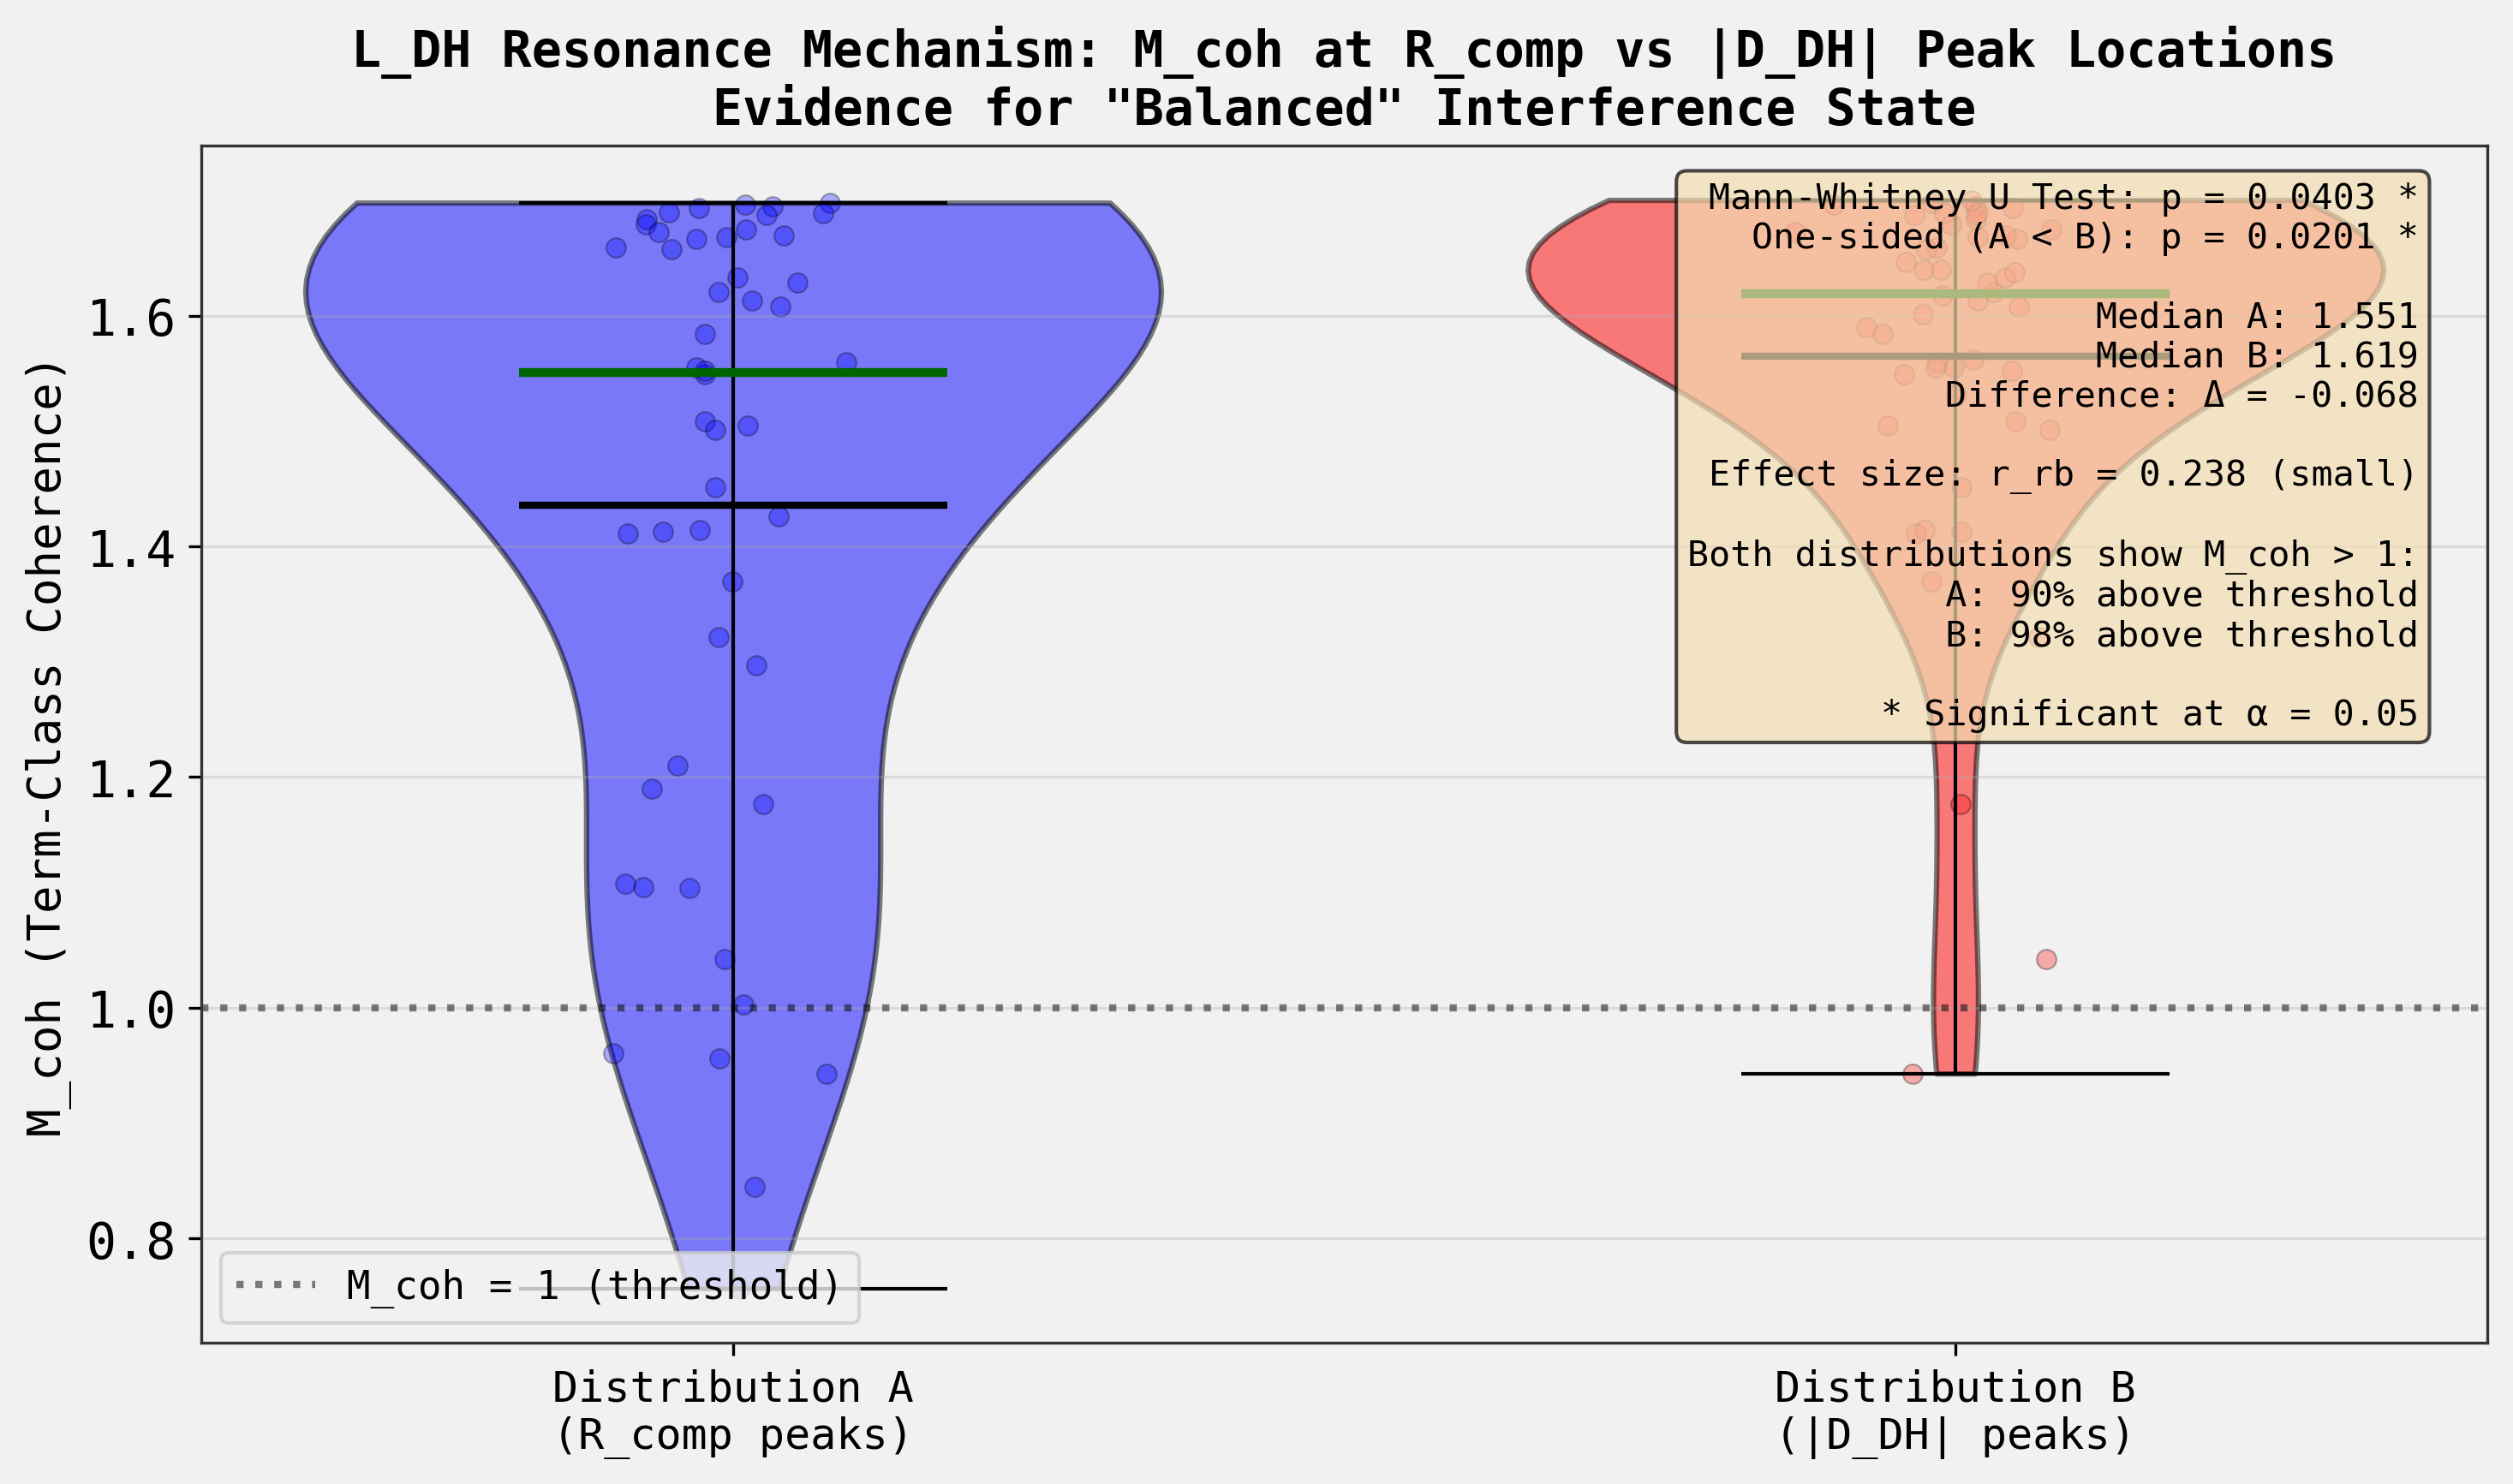

In [20]:

# Create final summary figure showing the key result
fig, ax = plt.subplots(figsize=(10, 6))

# Create side-by-side violin plots with box plots overlaid
positions = [1, 2]
parts = ax.violinplot([M_coh_at_R_comp_peaks, M_coh_at_D_DH_peaks], 
 positions=positions, widths=0.7,
 showmeans=True, showmedians=True)

# Color the violin plots
colors = ['blue', 'red']
for i, pc in enumerate(parts['bodies']):
 pc.set_facecolor(colors[i])
 pc.set_alpha(0.5)
 pc.set_edgecolor('black')
 pc.set_linewidth(1.5)

# Customize violin plot components
parts['cmeans'].set_color('black')
parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_color('darkgreen')
parts['cmedians'].set_linewidth(2.5)
parts['cbars'].set_color('black')
parts['cbars'].set_linewidth(1)
parts['cmaxes'].set_color('black')
parts['cmaxes'].set_linewidth(1)
parts['cmins'].set_color('black')
parts['cmins'].set_linewidth(1)

# Add horizontal line at M_coh = 1
ax.axhline(1.0, color='black', linestyle=':', linewidth=2, alpha=0.5, 
 label='M_coh = 1 (threshold)')

# Add scatter points for individual data
np.random.seed(42)
jitter_strength = 0.05
for i, (data, pos, color) in enumerate(zip([M_coh_at_R_comp_peaks, M_coh_at_D_DH_peaks], 
 positions, colors)):
 jitter = np.random.normal(0, jitter_strength, size=len(data))
 ax.scatter(pos + jitter, data, alpha=0.3, s=30, color=color, edgecolors='black', linewidth=0.5)

# Labels and title
ax.set_xticks(positions)
ax.set_xticklabels(['Distribution A\n(R_comp peaks)', 'Distribution B\n(|D_DH| peaks)'], fontsize=12)
ax.set_ylabel('M_coh (Term-Class Coherence)', fontsize=13)
ax.set_title('L_DH Resonance Mechanism: M_coh at R_comp vs |D_DH| Peak Locations\n' + 
 'Evidence for "Balanced" Interference State',
 fontsize=14, fontweight='bold')

# Add grid
ax.grid(True, alpha=0.3, axis='y')

# Add statistical annotation
median_diff = np.median(M_coh_at_R_comp_peaks) - np.median(M_coh_at_D_DH_peaks)
textstr = '\n'.join([
 f'Mann-Whitney U Test: p = {p_value:.4f} *',
 f'One-sided (A < B): p = {p_value_less:.4f} *',
 '',
 f'Median A: {np.median(M_coh_at_R_comp_peaks):.3f}',
 f'Median B: {np.median(M_coh_at_D_DH_peaks):.3f}',
 f'Difference: Δ = {median_diff:.3f}',
 '',
 f'Effect size: r_rb = {rank_biserial:.3f} (small)',
 '',
 'Both distributions show M_coh > 1:',
 f' A: {(M_coh_at_R_comp_peaks > 1).mean():.0%} above threshold',
 f' B: {(M_coh_at_D_DH_peaks > 1).mean():.0%} above threshold',
 '',
 '* Significant at α = 0.05'
])
ax.text(0.97, 0.97, textstr, transform=ax.transAxes, fontsize=10,
 verticalalignment='top', horizontalalignment='right',
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# Legend
ax.legend(loc='lower left', fontsize=11)

plt.tight_layout()
plt.savefig('ldh_resonance_final_figure.png', dpi=300, bbox_inches='tight')
print("Final figure saved as 'ldh_resonance_final_figure.png'")
plt.show()
